# Content-Based Filtering — MovieLens Latest Small

Instead of learning from rating patterns, content-based filtering recommends movies
similar in content to what the user has rated highly.

**Content vector per movie:**
```
[genre_1, genre_2, ..., genre_19, α · norm_year]   →  20 dimensions
```

**Item-item similarity:**
```
sim(i,j) = content_vec[i] · content_vec[j] / (||content_vec[i]|| · ||content_vec[j]||)
```

**Prediction — weighted average of user's training ratings on similar movies:**
```
r̂(u,i) = Σ_j sim(i,j) · r(u,j)  /  Σ_j sim(i,j)
```
where j ranges over the top-N most similar movies that user u has rated in training.

**Hyperparameters:**
- `α` — weight of year feature relative to genre features
- `N` — neighbourhood size (how many similar movies to use per prediction)


## 1. Imports & Load Data

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import json
import ast

BG, PANEL, GRID_C = "#0f0f14", "#16161f", "#2a2a35"
TEXT_C, ACCENT, ACCENT2, ACCENT3, ACCENT4 = "#d4d4e0", "#7DF9C4", "#F97D7D", "#7DA8F9", "#F9E07D"

def style_ax(ax, title):
    ax.set_facecolor(PANEL)
    ax.set_title(title, color=TEXT_C, fontsize=10, pad=9, fontweight="bold")
    ax.tick_params(colors=TEXT_C, labelsize=8)
    ax.xaxis.label.set_color(TEXT_C)
    ax.yaxis.label.set_color(TEXT_C)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID_C)
    ax.grid(color=GRID_C, linewidth=0.5, linestyle="--", alpha=0.7)

train  = pd.read_csv("../data/processed/train.csv")
test   = pd.read_csv("../data/processed/test.csv")
movies = pd.read_csv("../data/processed/movies_clean.csv")

N_USERS  = train.user_idx.nunique()
N_MOVIES = train.movie_idx.nunique()
RATING_MIN, RATING_MAX = 0.5, 5.0

# baseline targets
BASELINE_RMSE = 0.8573
BASELINE_MAE  = 0.6564

print(f"Users  : {N_USERS}")
print(f"Movies : {N_MOVIES}")
print(f"Train  : {len(train):,}  |  Test: {len(test):,}")
print(f"Movies with year: {movies.year.notna().sum()} / {len(movies)}")


Users  : 610
Movies : 2269
Train  : 65,130  |  Test: 15,986
Movies with year: 2269 / 2269


## 2. Build Content Vectors

**Genres:** 19 binary flags (multi-hot). A movie with genres `Action|Drama` gets 1s in both columns.

**Year:** normalised to [0,1] across the dataset range, then scaled by α.

Movies with missing year get `norm_year = 0.5` (midpoint) — neutral, doesn't push similarity in either direction.


In [6]:
ALPHA = 2.0   # year weight relative to genre dimensions

# ── Genre encoding ─────────────────────────────────────────────────────
ALL_GENRES = [
    "Action", "Adventure", "Animation", "Children", "Comedy",
    "Crime", "Documentary", "Drama", "Fantasy", "Film-Noir",
    "Horror", "Musical", "Mystery", "Romance", "Sci-Fi",
    "Thriller", "War", "Western", "IMAX"
]

genre_matrix = np.zeros((N_MOVIES, len(ALL_GENRES)))

for _, row in movies.iterrows():
    idx    = int(row["movie_idx"])
    genres = ast.literal_eval(row["genre_list"])
    for g in genres:
        if g in ALL_GENRES:
            genre_matrix[idx, ALL_GENRES.index(g)] = 1.0

print(f"Genre matrix shape : {genre_matrix.shape}")
print(f"Avg genres per movie: {genre_matrix.sum(axis=1).mean():.2f}")
print(f"Genre counts:")
for i, g in enumerate(ALL_GENRES):
    count = int(genre_matrix[:, i].sum())
    if count > 0:
        print(f"  {g:<15} {count:>4}")


Genre matrix shape : (2269, 19)
Avg genres per movie: 2.69
Genre counts:
  Action           658
  Adventure        500
  Animation        155
  Children         212
  Comedy           911
  Crime            342
  Documentary       20
  Drama            963
  Fantasy          261
  Film-Noir         24
  Horror           170
  Musical           92
  Mystery          174
  Romance          429
  Sci-Fi           358
  Thriller         599
  War              104
  Western           44
  IMAX              91


In [ ]:
# ── Year encoding ──────────────────────────────────────────────────────
#print(movies.head())
year_vals = movies.set_index("movie_idx")["year"].reindex(range(N_MOVIES))
#print(year_vals.head())
min_year = year_vals.min()
max_year = year_vals.max()
year_range = max_year - min_year

# normalise to [0,1], fill missing with 0.5
norm_year = ((year_vals - min_year) / year_range).fillna(0.5).values
print(f"Year range : {min_year:.0f} – {max_year:.0f}")
print(f"Norm year  : min={norm_year.min():.3f}  max={norm_year.max():.3f}  mean={norm_year.mean():.3f}")
print(f"Movies with missing year (filled with 0.5): {year_vals.isna().sum()}")
# ── Combine into content matrix ────────────────────────────────────────
content_matrix = np.hstack([
    genre_matrix,
    (ALPHA * norm_year).reshape(-1, 1)
])

print(f"\nContent matrix shape : {content_matrix.shape}  ({N_MOVIES} movies × {content_matrix.shape[1]} features)")
print(f"  Features: 19 genres + 1 weighted year (α={ALPHA})")


(2269,)
Year range : 1922 – 2018
Norm year  : min=0.000  max=1.000  mean=0.759
Movies with missing year (filled with 0.5): 0

Content matrix shape : (2269, 20)  (2269 movies × 20 features)
  Features: 19 genres + 1 weighted year (α=2.0)


## 3. Compute Item-Item Cosine Similarity

```
sim(i,j) = content_vec[i] · content_vec[j] / (||content_vec[i]|| · ||content_vec[j]||)
```

Result: a 2269×2269 symmetric similarity matrix where `sim[i,j] ∈ [0,1]`.
Values close to 1 = very similar content. Values close to 0 = very different.

Note: cosine similarity is always ≥ 0 here because all feature values are ≥ 0
(binary genre flags and normalised year). So no negative similarities.


In [14]:
# row-wise L2 normalisation
norms = np.linalg.norm(content_matrix, axis=1, keepdims=True)
norms = np.where(norms == 0, 1e-9, norms)   # avoid division by zero
content_normed = content_matrix / norms

# cosine similarity matrix — one matrix multiply
sim_matrix = content_normed @ content_normed.T

print(f"Similarity matrix shape : {sim_matrix.shape}")
print(f"sim range : {sim_matrix.min():.4f} – {sim_matrix.max():.4f}")
print(f"sim mean  : {sim_matrix.mean():.4f}")
print(f"sim diag  : {np.diag(sim_matrix).mean():.4f}  (should be 1.0 — self-similarity)")

# verify symmetry
print(f"Symmetric : {np.allclose(sim_matrix, sim_matrix.T)}")


Similarity matrix shape : (2269, 2269)
sim range : 0.0000 – 1.0000
sim mean  : 0.5971
sim diag  : 1.0000  (should be 1.0 — self-similarity)
Symmetric : True


### Sanity check — most similar movies

In [15]:
movie_lookup = movies.set_index("movie_idx")[["title_clean", "genres", "year"]]

def most_similar(movie_idx, n=5):
    sims = sim_matrix[movie_idx].copy()
    sims[movie_idx] = -1   # exclude self
    top  = np.argsort(sims)[-n:][::-1]
    src  = movie_lookup.loc[movie_idx]
    print(f"Query : {src.title_clean}  [{src.genres}]  ({src.year:.0f})")
    print(f"Most similar:")
    for idx in top:
        row = movie_lookup.loc[idx]
        print(f"  sim={sims[idx]:.3f}  {row.title_clean}  [{row.genres}]  ({row.year:.0f})")
    print()

# pick a few interesting movies to sanity check
toy_story_idx = movies[movies["title_clean"].str.contains("Toy Story", na=False)].iloc[0]["movie_idx"]
matrix_idx    = movies[movies["title_clean"].str.contains("Matrix", na=False)].iloc[0]["movie_idx"]
fargo_idx     = movies[movies["title_clean"].str.contains("Fargo", na=False)].iloc[0]["movie_idx"]

most_similar(int(toy_story_idx))
most_similar(int(matrix_idx))
most_similar(int(fargo_idx))


Query : Toy Story  [Adventure|Animation|Children|Comedy|Fantasy]  (1995)
Most similar:
  sim=1.000  Antz  [Adventure|Animation|Children|Comedy|Fantasy]  (1998)
  sim=1.000  Toy Story 2  [Adventure|Animation|Children|Comedy|Fantasy]  (1999)
  sim=1.000  Emperor's New Groove, The  [Adventure|Animation|Children|Comedy|Fantasy]  (2000)
  sim=0.999  Monsters, Inc.  [Adventure|Animation|Children|Comedy|Fantasy]  (2001)
  sim=0.997  Shrek the Third  [Adventure|Animation|Children|Comedy|Fantasy]  (2007)

Query : Matrix, The  [Action|Sci-Fi|Thriller]  (1999)
Most similar:
  sim=1.000  eXistenZ  [Action|Sci-Fi|Thriller]  (1999)
  sim=1.000  6th Day, The  [Action|Sci-Fi|Thriller]  (2000)
  sim=1.000  Red Planet  [Action|Sci-Fi|Thriller]  (2000)
  sim=1.000  Godzilla  [Action|Sci-Fi|Thriller]  (1998)
  sim=1.000  One, The  [Action|Sci-Fi|Thriller]  (2001)

Query : Fargo  [Comedy|Crime|Drama|Thriller]  (1996)
Most similar:
  sim=1.000  Pulp Fiction  [Comedy|Crime|Drama|Thriller]  (1994)
  sim=0.999

## 4. Content-Based Prediction

For each (user, movie) pair in the test set:

1. Find movies the user rated in training
2. Compute similarity between test movie and each training movie
3. Take top-N most similar training movies (neighbourhood)
4. Predict as similarity-weighted average of their ratings:

```
r̂(u,i) = Σ_j sim(i,j)·r(u,j) / Σ_j sim(i,j)
```

If the user has no training ratings with positive similarity to movie i,
fall back to the user's mean training rating.


In [16]:
N_NEIGHBOURS = 30   # neighbourhood size

# precompute user training ratings as dict: user_idx → {movie_idx: rating}
user_train_ratings = (
    train.groupby("user_idx")
         .apply(lambda df: dict(zip(df["movie_idx"], df["rating"])))
         .to_dict()
)

user_train_means = train.groupby("user_idx")["rating"].mean().to_dict()

def predict_content(user_idx, movie_idx):
    """Predict rating for (user, movie) using content-based filtering."""
    rated = user_train_ratings.get(user_idx, {})
    if not rated:
        return user_train_means.get(user_idx, train["rating"].mean())

    rated_idxs   = np.array(list(rated.keys()))
    rated_ratings = np.array(list(rated.values()), dtype=float)

    # similarity between target movie and all rated movies
    sims = sim_matrix[movie_idx, rated_idxs]

    # take top-N neighbours with positive similarity
    top_mask = np.argsort(sims)[-N_NEIGHBOURS:]
    top_sims = sims[top_mask]
    top_ratings = rated_ratings[top_mask]

    # filter out zero similarity
    pos_mask = top_sims > 0
    if pos_mask.sum() == 0:
        return user_train_means.get(user_idx, train["rating"].mean())

    return np.dot(top_sims[pos_mask], top_ratings[pos_mask]) / top_sims[pos_mask].sum()


def predict_content_batch(user_idxs, movie_idxs):
    """Vectorised prediction for arrays of (user, movie) pairs."""
    return np.array([
        predict_content(u, i)
        for u, i in zip(user_idxs, movie_idxs)
    ])


## 5. Content-Based Recommendation

In [17]:
def recommend_content(user_idx, n=10, seen_items=None):
    """
    Score all unseen movies for a user using content-based prediction.
    Returns top-N (movie_idx, score) pairs.
    """
    all_movies = np.arange(N_MOVIES)
    if seen_items is not None:
        mask       = ~np.isin(all_movies, list(seen_items))
        candidates = all_movies[mask]
    else:
        candidates = all_movies

    scores = np.array([predict_content(user_idx, i) for i in candidates])
    scores = np.clip(scores, RATING_MIN, RATING_MAX)

    top_idx = np.argpartition(scores, -n)[-n:]
    top_idx = top_idx[np.argsort(scores[top_idx])[::-1]]
    return list(zip(candidates[top_idx], scores[top_idx]))


## 6. Evaluate

In [18]:
def rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted) ** 2))

def mae(actual, predicted):
    return np.mean(np.abs(actual - predicted))

def ndcg_at_k(recommend_fn, test_df, train_df, k=10, threshold=4.0):
    train_seen = train_df.groupby("user_idx")["movie_idx"].apply(set).to_dict()
    test_relevant = (
        test_df[test_df["rating"] >= threshold]
        .groupby("user_idx")["movie_idx"]
        .apply(set)
        .to_dict()
    )
    ndcg_scores = []
    for user_idx, relevant in test_relevant.items():
        seen = train_seen.get(user_idx, set())
        recs = recommend_fn(user_idx, k, seen)
        dcg  = sum(1.0 / np.log2(r + 1)
                   for r, (m, _) in enumerate(recs, 1) if m in relevant)
        n_hits = min(len(relevant), k)
        idcg   = sum(1.0 / np.log2(r + 1) for r in range(1, n_hits + 1))
        ndcg_scores.append(dcg / idcg if idcg > 0 else 0.0)
    return np.mean(ndcg_scores)

def precision_recall_at_k(recommend_fn, test_df, train_df, k=10, threshold=4.0):
    train_seen = train_df.groupby("user_idx")["movie_idx"].apply(set).to_dict()
    test_relevant = (
        test_df[test_df["rating"] >= threshold]
        .groupby("user_idx")["movie_idx"]
        .apply(set)
        .to_dict()
    )
    precisions, recalls = [], []
    for user_idx, relevant in test_relevant.items():
        seen    = train_seen.get(user_idx, set())
        recs    = recommend_fn(user_idx, k, seen)
        rec_set = {m for m, _ in recs}
        hits    = len(rec_set & relevant)
        precisions.append(hits / k)
        recalls.append(hits / len(relevant) if relevant else 0.0)
    p, r = np.mean(precisions), np.mean(recalls)
    f1   = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
    return p, r, f1

def coverage(recommend_fn, train_df, n_movies, k=10):
    train_seen = train_df.groupby("user_idx")["movie_idx"].apply(set).to_dict()
    recommended = set()
    for user_idx in train_df["user_idx"].unique():
        seen = train_seen.get(user_idx, set())
        recs = recommend_fn(user_idx, k, seen)
        recommended.update(m for m, _ in recs)
    return len(recommended) / n_movies

def random_baseline_pk(test_df, train_df, k=10, threshold=4.0, n_movies=N_MOVIES):
    train_seen = train_df.groupby("user_idx")["movie_idx"].apply(set).to_dict()
    test_relevant = (
        test_df[test_df["rating"] >= threshold]
        .groupby("user_idx")["movie_idx"]
        .apply(set)
        .to_dict()
    )
    precisions = []
    for user_idx, relevant in test_relevant.items():
        seen      = train_seen.get(user_idx, set())
        unseen    = set(range(n_movies)) - seen
        n_rel     = len(relevant & unseen)
        precisions.append(n_rel / len(unseen) if unseen else 0.0)
    return np.mean(precisions)

print("Evaluating content-based model...")
print("(This may take a few minutes — prediction loops over all test pairs)")
print()

# RMSE / MAE
print("Computing RMSE/MAE...")
test_preds = np.clip(
    predict_content_batch(test["user_idx"].values, test["movie_idx"].values),
    RATING_MIN, RATING_MAX
)
cb_rmse = rmse(test["rating"].values, test_preds)
cb_mae  = mae(test["rating"].values, test_preds)

# Ranking metrics
K = 10
print("Computing ranking metrics...")
p, r, f1 = precision_recall_at_k(recommend_content, test, train, k=K)
ndcg      = ndcg_at_k(recommend_content, test, train, k=K)
cov       = coverage(recommend_content, train, N_MOVIES, k=K)
p_random  = random_baseline_pk(test, train, k=K)

print()
print("=" * 60)
print("  Content-Based Filtering Results")
print("=" * 60)
print(f"  {'Metric':<20} {'Value':>8}  Note")
print(f"  {'-'*55}")
print(f"  {'RMSE':<20} {cb_rmse:>8.4f}  primary metric")
print(f"  {'MAE':<20} {cb_mae:>8.4f}  primary metric")
print(f"  {'NDCG@'+str(K):<20} {ndcg:>8.4f}  ranking quality")
print(f"  {'Precision@'+str(K):<20} {p:>8.4f}  lower bound")
print(f"  {'Recall@'+str(K):<20} {r:>8.4f}  lower bound")
print(f"  {'F1@'+str(K):<20} {f1:>8.4f}  lower bound")
print(f"  {'Coverage@'+str(K):<20} {cov:>8.4f}  catalog coverage")
print(f"  {'Random P@'+str(K):<20} {p_random:>8.4f}  random baseline")
print(f"  {'Lift over random':<20} {p/p_random:>7.1f}×")
print("=" * 60)


Evaluating content-based model...
(This may take a few minutes — prediction loops over all test pairs)

Computing RMSE/MAE...
Computing ranking metrics...

  Content-Based Filtering Results
  Metric                  Value  Note
  -------------------------------------------------------
  RMSE                   0.9027  primary metric
  MAE                    0.6980  primary metric
  NDCG@10                0.0160  ranking quality
  Precision@10           0.0149  lower bound
  Recall@10              0.0092  lower bound
  F1@10                  0.0113  lower bound
  Coverage@10            0.5663  catalog coverage
  Random P@10            0.0070  random baseline
  Lift over random         2.1×


## 7. Hyperparameter Sweep — α and N

Sweep α (year weight) and N (neighbourhood size) to find the best config.
Uses RMSE as the primary metric since it's faster to compute than ranking metrics.


In [19]:
alpha_vals = [0.5, 1.0, 2.0, 3.0, 5.0]
n_neighbour_vals = [10, 20, 30, 50]

sweep_results = []

for alpha in alpha_vals:
    # rebuild content matrix with this alpha
    cm = np.hstack([genre_matrix, (alpha * norm_year).reshape(-1, 1)])
    norms_a = np.linalg.norm(cm, axis=1, keepdims=True)
    norms_a = np.where(norms_a == 0, 1e-9, norms_a)
    cm_normed = cm / norms_a
    sim_a = cm_normed @ cm_normed.T

    for n_neigh in n_neighbour_vals:
        # predict on test set
        preds = []
        for u, i in zip(test["user_idx"].values, test["movie_idx"].values):
            rated = user_train_ratings.get(u, {})
            if not rated:
                preds.append(user_train_means.get(u, train["rating"].mean()))
                continue
            rated_idxs    = np.array(list(rated.keys()))
            rated_ratings  = np.array(list(rated.values()), dtype=float)
            sims           = sim_a[i, rated_idxs]
            top_mask       = np.argsort(sims)[-n_neigh:]
            top_sims       = sims[top_mask]
            top_ratings    = rated_ratings[top_mask]
            pos_mask       = top_sims > 0
            if pos_mask.sum() == 0:
                preds.append(user_train_means.get(u, train["rating"].mean()))
            else:
                preds.append(np.dot(top_sims[pos_mask], top_ratings[pos_mask]) / top_sims[pos_mask].sum())

        preds = np.clip(preds, RATING_MIN, RATING_MAX)
        r_val = rmse(test["rating"].values, preds)
        m_val = mae(test["rating"].values, preds)
        sweep_results.append({"alpha": alpha, "n_neighbours": n_neigh,
                               "rmse": r_val, "mae": m_val})
        print(f"  α={alpha:<4}  N={n_neigh:<3}  RMSE={r_val:.4f}  MAE={m_val:.4f}")

sweep_df = pd.DataFrame(sweep_results).sort_values("rmse")
print(f"\nBest config:")
print(sweep_df.iloc[0].to_string())


  α=0.5   N=10   RMSE=0.9138  MAE=0.7045
  α=0.5   N=20   RMSE=0.9029  MAE=0.6978
  α=0.5   N=30   RMSE=0.9002  MAE=0.6954
  α=0.5   N=50   RMSE=0.9010  MAE=0.6970
  α=1.0   N=10   RMSE=0.9136  MAE=0.7045
  α=1.0   N=20   RMSE=0.9033  MAE=0.6981
  α=1.0   N=30   RMSE=0.9010  MAE=0.6962
  α=1.0   N=50   RMSE=0.9019  MAE=0.6981
  α=2.0   N=10   RMSE=0.9140  MAE=0.7045
  α=2.0   N=20   RMSE=0.9041  MAE=0.6989
  α=2.0   N=30   RMSE=0.9027  MAE=0.6980
  α=2.0   N=50   RMSE=0.9040  MAE=0.7003
  α=3.0   N=10   RMSE=0.9138  MAE=0.7045
  α=3.0   N=20   RMSE=0.9057  MAE=0.7005
  α=3.0   N=30   RMSE=0.9040  MAE=0.6992
  α=3.0   N=50   RMSE=0.9057  MAE=0.7019
  α=5.0   N=10   RMSE=0.9159  MAE=0.7061
  α=5.0   N=20   RMSE=0.9068  MAE=0.7012
  α=5.0   N=30   RMSE=0.9051  MAE=0.7006
  α=5.0   N=50   RMSE=0.9074  MAE=0.7034

Best config:
alpha            0.500000
n_neighbours    30.000000
rmse             0.900228
mae              0.695372


## 8. Visualisation

C:\Users\Hites\AppData\Local\Temp\ipykernel_38888\107930729.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


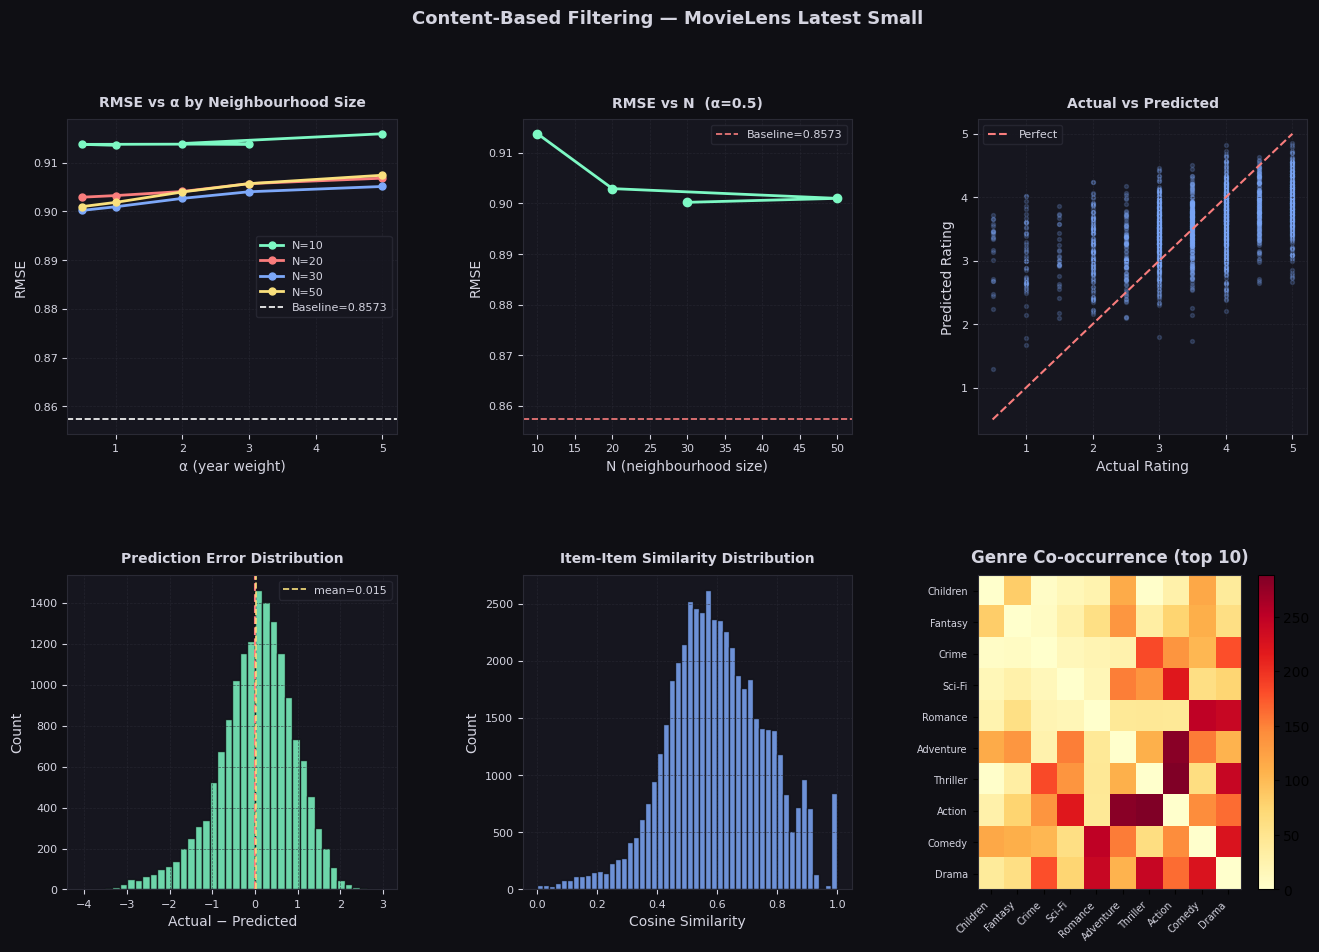

In [20]:
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor(BG)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

actual = test["rating"].values

# (a) RMSE vs alpha for each N
ax = fig.add_subplot(gs[0, 0])
colors_n = [ACCENT, ACCENT2, ACCENT3, ACCENT4]
for c, n_neigh in zip(colors_n, n_neighbour_vals):
    subset = sweep_df[sweep_df.n_neighbours == n_neigh]
    ax.plot(subset["alpha"], subset["rmse"], color=c, lw=2,
            marker="o", markersize=5, label=f"N={n_neigh}")
ax.axhline(BASELINE_RMSE, color="white", lw=1.2, linestyle="--",
           label=f"Baseline={BASELINE_RMSE}")
ax.set_xlabel("α (year weight)"); ax.set_ylabel("RMSE")
ax.legend(facecolor=PANEL, edgecolor=GRID_C, labelcolor=TEXT_C, fontsize=8)
style_ax(ax, "RMSE vs α by Neighbourhood Size")

# (b) RMSE vs N for best alpha
best_alpha = sweep_df.iloc[0]["alpha"]
ax = fig.add_subplot(gs[0, 1])
subset = sweep_df[sweep_df.alpha == best_alpha]
ax.plot(subset["n_neighbours"], subset["rmse"],
        color=ACCENT, lw=2, marker="o", markersize=6)
ax.axhline(BASELINE_RMSE, color=ACCENT2, lw=1.2, linestyle="--",
           label=f"Baseline={BASELINE_RMSE}")
ax.set_xlabel("N (neighbourhood size)"); ax.set_ylabel("RMSE")
ax.legend(facecolor=PANEL, edgecolor=GRID_C, labelcolor=TEXT_C, fontsize=8)
style_ax(ax, f"RMSE vs N  (α={best_alpha})")

# (c) Actual vs predicted scatter
ax = fig.add_subplot(gs[0, 2])
sample = np.random.default_rng(0).choice(len(test_preds), min(2000, len(test_preds)), replace=False)
ax.scatter(actual[sample], test_preds[sample], alpha=0.2, s=8, color=ACCENT3)
ax.plot([RATING_MIN, RATING_MAX], [RATING_MIN, RATING_MAX],
        color=ACCENT2, lw=1.5, linestyle="--", label="Perfect")
ax.set_xlabel("Actual Rating"); ax.set_ylabel("Predicted Rating")
ax.legend(facecolor=PANEL, edgecolor=GRID_C, labelcolor=TEXT_C, fontsize=8)
style_ax(ax, "Actual vs Predicted")

# (d) Error distribution
ax = fig.add_subplot(gs[1, 0])
errors = actual - test_preds
ax.hist(errors, bins=40, color=ACCENT, edgecolor=BG, alpha=0.85)
ax.axvline(0, color=ACCENT2, lw=1.5, linestyle="--")
ax.axvline(errors.mean(), color=ACCENT4, lw=1.2, linestyle="--",
           label=f"mean={errors.mean():.3f}")
ax.set_xlabel("Actual − Predicted"); ax.set_ylabel("Count")
ax.legend(facecolor=PANEL, edgecolor=GRID_C, labelcolor=TEXT_C, fontsize=8)
style_ax(ax, "Prediction Error Distribution")

# (e) Similarity distribution
ax = fig.add_subplot(gs[1, 1])
# sample off-diagonal similarities
sample_sims = sim_matrix[np.triu_indices(N_MOVIES, k=1)]
sample_sims = sample_sims[np.random.default_rng(0).choice(len(sample_sims),
                           min(50000, len(sample_sims)), replace=False)]
ax.hist(sample_sims, bins=50, color=ACCENT3, edgecolor=BG, alpha=0.85)
ax.set_xlabel("Cosine Similarity"); ax.set_ylabel("Count")
style_ax(ax, "Item-Item Similarity Distribution")

# (f) Genre co-occurrence heatmap (top 10 genres)
ax = fig.add_subplot(gs[1, 2])
top10_idx = np.argsort(genre_matrix.sum(axis=0))[-10:]
top10_genres = [ALL_GENRES[i] for i in top10_idx]
cooccurrence = genre_matrix[:, top10_idx].T @ genre_matrix[:, top10_idx]
np.fill_diagonal(cooccurrence, 0)
im = ax.imshow(cooccurrence, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(10)); ax.set_xticklabels(top10_genres, rotation=45, ha="right",
                                               fontsize=7, color=TEXT_C)
ax.set_yticks(range(10)); ax.set_yticklabels(top10_genres, fontsize=7, color=TEXT_C)
ax.set_title("Genre Co-occurrence (top 10)", color=TEXT_C, fontweight="bold", pad=9)
ax.set_facecolor(PANEL)
for spine in ax.spines.values(): spine.set_edgecolor(GRID_C)
plt.colorbar(im, ax=ax)

fig.suptitle("Content-Based Filtering — MovieLens Latest Small",
             color=TEXT_C, fontsize=13, fontweight="bold", y=0.99)
plt.tight_layout()
plt.show()


## 9. Sample Recommendations

In [21]:
def show_recommendations(user_idx, n=10):
    user_train = train[train["user_idx"] == user_idx].merge(
        movies[["movie_idx", "title_clean", "genres"]], on="movie_idx"
    ).sort_values("rating", ascending=False)

    print(f"User {user_idx} — top rated in train:")
    for _, row in user_train.head(5).iterrows():
        print(f"  {row['rating']:.1f}  {row['title_clean']}  [{row['genres']}]")
    print()

    seen = set(train[train["user_idx"] == user_idx]["movie_idx"].values)
    recs = recommend_content(user_idx, n=n, seen_items=seen)

    print(f"  Top-{n} content-based recommendations:")
    print(f"  {'Rank':<5} {'Title':<45} {'Genres':<35} {'Score':>5}")
    print("  " + "─" * 92)
    for rank, (midx, score) in enumerate(recs, 1):
        row    = movie_lookup.loc[midx]
        title  = str(row["title_clean"])[:43]
        genres = str(row["genres"])[:33]
        print(f"  {rank:<5} {title:<45} {genres:<35} {score:>5.3f}")
    print()

for uid in [0, 42, 100]:
    print("=" * 95)
    show_recommendations(uid)


User 0 — top rated in train:
  5.0  Winnie the Pooh and the Blustery Day  [Animation|Children|Musical]
  5.0  Seven (a.k.a. Se7en)  [Mystery|Thriller]
  5.0  Back to the Future  [Adventure|Comedy|Sci-Fi]
  5.0  Rob Roy  [Action|Drama|Romance|War]
  5.0  Robin Hood  [Adventure|Animation|Children|Comedy|Musical]

  Top-10 content-based recommendations:
  Rank  Title                                         Genres                              Score
  ────────────────────────────────────────────────────────────────────────────────────────────
  1     Hunchback of Notre Dame, The                  Animation|Children|Drama|Musical|   4.828
  2     Pocahontas                                    Animation|Children|Drama|Musical|   4.828
  3     Battleship Potemkin                           Drama|War                           4.701
  4     Grave of the Fireflies (Hotaru no haka)       Animation|Drama|War                 4.698
  5     Meet Me in St. Louis                          Musical           

## 10. Save Results

In [22]:
best_config = sweep_df.iloc[0]

results_cb = {
    "rmse":           cb_rmse,
    "mae":            cb_mae,
    "ndcg_at_10":     ndcg,
    "precision_at_10": p,
    "recall_at_10":   r,
    "f1_at_10":       f1,
    "coverage":       cov,
    "best_alpha":     float(best_config["alpha"]),
    "best_n":         int(best_config["n_neighbours"]),
}

with open("results_content_based.json", "w") as f:
    json.dump(results_cb, f, indent=2)

# save content matrix and similarity matrix for hybrid notebook
np.save("content_matrix.npy", content_matrix)
np.save("sim_matrix.npy",     sim_matrix)
np.save("norm_year.npy",      norm_year)
np.save("genre_matrix.npy",   genre_matrix)

print("Saved: results_content_based.json")
print("Saved: content_matrix.npy, sim_matrix.npy, norm_year.npy, genre_matrix.npy")
print()
print(json.dumps(results_cb, indent=2))


Saved: results_content_based.json
Saved: content_matrix.npy, sim_matrix.npy, norm_year.npy, genre_matrix.npy

{
  "rmse": 0.9026901370814241,
  "mae": 0.6980156602199765,
  "ndcg_at_10": 0.01595565239448019,
  "precision_at_10": 0.01488294314381271,
  "recall_at_10": 0.009153159374024736,
  "f1_at_10": 0.011335111459836032,
  "coverage": 0.5663287791978845,
  "best_alpha": 0.5,
  "best_n": 30
}
